# Fase 3: MLOps - Final
## Data Drift


Este notebook evalúa cómo cambios artificiales en la distribución de los datos impactan el desempeño del modelo entrenado. A partir del conjunto de validación, se generan escenarios de data drift (desplazamiento de medias, aumento de datos faltantes y variación estacional) y se comparan las métricas resultantes contra la línea base. Esto permite identificar degradación en la performance y establecer umbrales y acciones de alerta dentro del flujo de MLOps.


## Carga de base de datos

In [54]:
#Import necessary libraries
from pathlib import Path

# Define project root directory
PROJECT_ROOT = Path("..").resolve()
print("PROJECT_ROOT:", PROJECT_ROOT)

# Define processed data directory
processed_dir = PROJECT_ROOT / "data" / "processed"
print("Contenido real de data/processed:")
list(processed_dir.glob("*"))

PROJECT_ROOT: /Users/angelgo/VSC/insurance_company_project
Contenido real de data/processed:


[PosixPath('/Users/angelgo/VSC/insurance_company_project/data/processed/X_test.parquet.dvc'),
 PosixPath('/Users/angelgo/VSC/insurance_company_project/data/processed/insurance_company_cleaned_modified.csv.dvc'),
 PosixPath('/Users/angelgo/VSC/insurance_company_project/data/processed/y_test.parquet.dvc'),
 PosixPath('/Users/angelgo/VSC/insurance_company_project/data/processed/.gitkeep'),
 PosixPath('/Users/angelgo/VSC/insurance_company_project/data/processed/.gitignore'),
 PosixPath('/Users/angelgo/VSC/insurance_company_project/data/processed/insurance_company_cleaned_modified.csv')]

In [55]:
# Load processed data
from src.dataset import load_processed_data

# Define data path 
DATA_PATH = processed_dir / "insurance_company_cleaned_modified.csv"
print("Usando ruta:", DATA_PATH)

df = load_processed_data(DATA_PATH)

print("Shape:", df.shape)
df.head()

2025-11-17 19:45:19,958 - INFO - Loaded processed data from: /Users/angelgo/VSC/insurance_company_project/data/processed/insurance_company_cleaned_modified.csv


Usando ruta: /Users/angelgo/VSC/insurance_company_project/data/processed/insurance_company_cleaned_modified.csv
Shape: (5938, 86)


,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,CARAVAN
0,33,1,3,2,8,0,5,1,3,7,...,1,1,1,1,1,1,1,1,1,0
1,37,1,2,2,8,1,4,0,4,6,...,1,1,1,1,1,1,1,1,1,0
2,37,1,2,2,8,0,4,2,4,3,...,1,1,1,1,1,1,1,1,1,0
3,9,1,3,3,3,2,3,2,4,5,...,1,1,1,1,1,1,1,1,1,0
4,40,1,4,2,10,1,4,1,4,7,...,1,1,1,1,1,1,1,1,1,0


## Flujo de Drift


In [56]:
# Deine target and features
df.columns.tolist()

TARGET_COL = "CARAVAN" 

X_base = df.drop(columns=[TARGET_COL])
y_base = df[TARGET_COL]

print("X_base:", X_base.shape)
print("y_base:", y_base.shape)
X_base.head()

X_base: (5938, 85)
y_base: (5938,)


,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
0,33,1,3,2,8,0,5,1,3,7,...,1,1,1,1,1,1,1,1,1,1
1,37,1,2,2,8,1,4,0,4,6,...,1,1,1,1,1,1,1,1,1,1
2,37,1,2,2,8,0,4,2,4,3,...,1,1,1,1,1,1,1,1,1,1
3,9,1,3,3,3,2,3,2,4,5,...,1,1,1,1,1,1,1,1,1,1
4,40,1,4,2,10,1,4,1,4,7,...,1,1,1,1,1,1,1,1,1,1


In [57]:
# Check models directory
from pathlib import Path

models_dir = PROJECT_ROOT / "models"
print("Contenido de models/:")
list(models_dir.glob("*"))

Contenido de models/:


[PosixPath('/Users/angelgo/VSC/insurance_company_project/models/.gitkeep'),
 PosixPath('/Users/angelgo/VSC/insurance_company_project/models/.gitignore'),
 PosixPath('/Users/angelgo/VSC/insurance_company_project/models/model_xgb_final.pkl.dvc')]

Para los experimentos de data drift se entrenó un modelo de clasificación sobre el dataset procesado, manteniendo el mismo esquema de features y target que el modelo principal del proyecto.

In [58]:
# Split Train/Test

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((4750, 85), (1188, 85), (4750,), (1188,))

In [59]:
# Model Training > RamdomForestClassifier

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Modelo entrenado ✅")

Modelo entrenado ✅


In [60]:
# Model validation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X, y, label="baseline"):
    y_pred = model.predict(X)
    return {
        "scenario": label,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
    }

baseline_metrics = evaluate_model(model, X_val, y_val, label="baseline")
baseline_metrics

{'scenario': 'baseline',
 'accuracy': 0.9318181818181818,
 'precision': 0.13333333333333333,
 'recall': 0.02857142857142857,
 'f1': 0.047058823529411764}

## Drift Scenarios


In [61]:
# Prepare data for monitoring

X_monitor = X_val.copy()
y_monitor = y_val.copy()

X_monitor.shape, y_monitor.shape

((1188, 85), (1188,))

In [62]:
# Identify numerical columns

import numpy as np

num_cols = X_monitor.select_dtypes(include=["number"]).columns
print("Columnas numéricas detectadas:", len(num_cols))
num_cols[:10]

Columnas numéricas detectadas: 85


Index(['MOSTYPE', 'MAANTHUI', 'MGEMOMV', 'MGEMLEEF', 'MOSHOOFD', 'MGODRK',
       'MGODPR', 'MGODOV', 'MGODGE', 'MRELGE'],
      dtype='object')

### Scenario 1: Drift por desplazamiento de medias (+20%)

Escenario que simula cambio de contexto, los valores de muchas variables suben.

In [63]:
X_drift_mean = X_monitor.copy()
X_drift_mean[num_cols] = X_drift_mean[num_cols] * 1.2  # +20%

X_drift_mean.head()

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
1375,37.2,1.2,3.6,2.4,8.4,2.4,2.4,0.0,6.0,7.2,...,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2
1612,27.6,1.2,1.2,2.4,6.0,0.0,7.2,1.2,2.4,1.2,...,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2
1774,36.0,1.2,3.6,3.6,10.8,0.0,3.6,0.0,7.2,8.4,...,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2
5515,9.6,1.2,2.4,3.6,2.4,0.0,7.2,0.0,3.6,10.8,...,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2
3725,38.4,1.2,3.6,3.6,8.4,1.2,6.0,1.2,3.6,6.0,...,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2


### Scenario 2: Drift por datos faltantes (missingness)

Escenario que simula fallas en la captura de datos.

In [64]:
X_drift_missing = X_monitor.copy()

np.random.seed(42)
mask = np.random.rand(*X_drift_missing[num_cols].shape) < 0.15  # 15% de NaNs
X_drift_missing[num_cols] = X_drift_missing[num_cols].mask(mask)

X_drift_missing.head()

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
1375,31.0,1.0,3.0,2.0,7.0,2.0,NaN,0.0,5.0,6.0,...,1.0,1.0,NaN,1.0,NaN,1.0,1.0,1.0,NaN,1.0
1612,23.0,1.0,1.0,2.0,5.0,NaN,6.0,1.0,2.0,1.0,...,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,1.0
1774,30.0,NaN,3.0,3.0,9.0,0.0,3.0,0.0,6.0,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5515,8.0,1.0,2.0,3.0,NaN,0.0,6.0,NaN,3.0,9.0,...,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN
3725,32.0,1.0,3.0,3.0,7.0,1.0,5.0,NaN,3.0,5.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN


In [65]:
X_drift_missing_imputed = X_drift_missing.copy()

for col in num_cols:
    median_val = X_drift_missing_imputed[col].median()
    X_drift_missing_imputed[col] = X_drift_missing_imputed[col].fillna(median_val)

### Scenario 3: Drift estacional en algunas variables (FUERTE)

Escenario que simula estacionalidad, tomamos algunas columnas y metemos un desplazamiento aleatorio discreto buscando generar un cambio que detone Alerta.

In [100]:
cols_shuffle = list(num_cols[:10]) 
print("Columnas permutadas (drift fuerte):", cols_shuffle)

X_drift_season = X_monitor.copy()

for c in cols_shuffle:
    X_drift_season[c] = np.random.permutation(X_drift_season[c].values)

metrics_season = evaluate_model(model, X_drift_season, y_monitor, label="season_drift")

results = [
    metrics_baseline,
    metrics_mean,
    metrics_missing,
    metrics_season
]

results_df = pd.DataFrame(results)
results_df

Columnas permutadas (drift fuerte): ['MOSTYPE', 'MAANTHUI', 'MGEMOMV', 'MGEMLEEF', 'MOSHOOFD', 'MGODRK', 'MGODPR', 'MGODOV', 'MGODGE', 'MRELGE']


,scenario,accuracy,precision,recall,f1
0,baseline,0.935185,0.111111,0.014286,0.025316
1,mean_drift,0.938552,0.200000,0.014286,0.026667
2,missing_drift,0.939394,0.000000,0.000000,0.000000
3,season_drift,0.940236,0.000000,0.000000,0.000000


## Evaluación de Performance

In [97]:
metrics_baseline = evaluate_model(model, X_monitor, y_monitor, label="baseline")
metrics_mean = evaluate_model(model, X_drift_mean, y_monitor, label="mean_drift")
metrics_missing = evaluate_model(model, X_drift_missing_imputed, y_monitor, label="missing_drift")
metrics_season = evaluate_model(model, X_drift_season, y_monitor, label="season_drift")

results = [metrics_baseline, metrics_mean, metrics_missing, metrics_season]

import pandas as pd
results_df = pd.DataFrame(results)
results_df

,scenario,accuracy,precision,recall,f1
0,baseline,0.935185,0.111111,0.014286,0.025316
1,mean_drift,0.938552,0.200000,0.014286,0.026667
2,missing_drift,0.939394,0.000000,0.000000,0.000000
3,season_drift,0.941077,0.000000,0.000000,0.000000


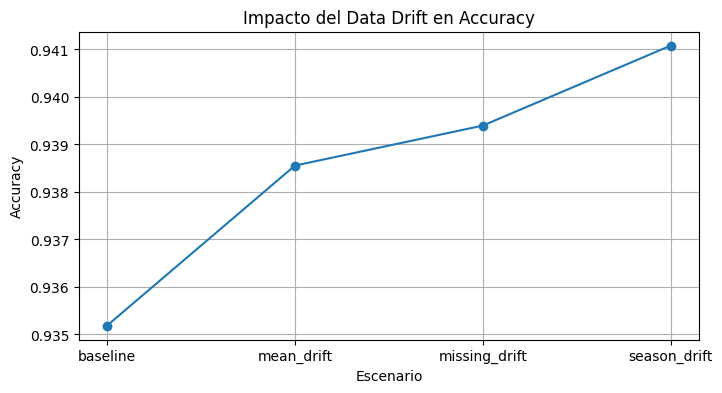

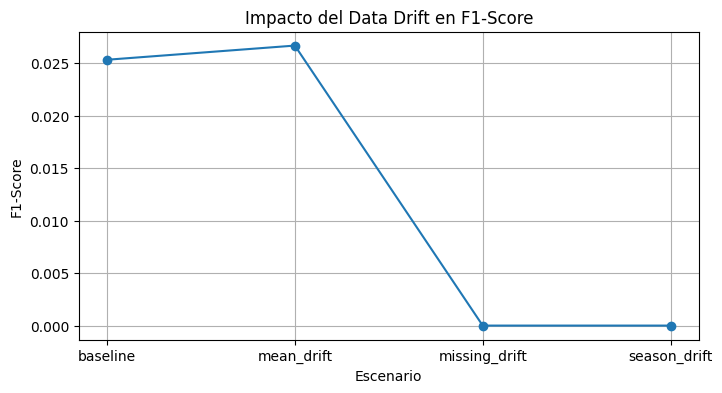

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(results_df["scenario"], results_df["accuracy"], marker="o")
plt.title("Impacto del Data Drift en Accuracy")
plt.xlabel("Escenario")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(results_df["scenario"], results_df["f1"], marker="o")
plt.title("Impacto del Data Drift en F1-Score")
plt.xlabel("Escenario")
plt.ylabel("F1-Score")
plt.grid(True)
plt.show()

## Definición de Alertas

Generamos la siguiente regla: 
Si el accuracy cae más de 2 puntos porcentuales vs baseline > Alerta


In [99]:
baseline_acc = metrics_baseline["accuracy"]
threshold_drop = 0.02

def check_alert(scenario_metrics):
    drop = baseline_acc - scenario_metrics["accuracy"]
    return {
        "scenario": scenario_metrics["scenario"],
        "accuracy": scenario_metrics["accuracy"],
        "drop": drop,
        "alert": drop > threshold_drop,
    }

alerts = [check_alert(m) for m in results]
alerts_df = pd.DataFrame(alerts)
alerts_df

,scenario,accuracy,drop,alert
0,baseline,0.935185,0.000000,False
1,mean_drift,0.938552,-0.003367,False
2,missing_drift,0.939394,-0.004209,False
3,season_drift,0.941077,-0.005892,False
